# Week 06: IPO & distribution shapes — **self-paced**

**Course:** MATH7810 Python for Data Science (AY2026/27)  
Work through the tasks **in order**. The instructor will **walk around**. Ask if you are stuck after the “If you are stuck” steps.

**This notebook:** Binomial shape, standardizing $Z$, continuity correction, Normal quantile.  


## How to work today

| Step | What you do |
|------|----------------|
| 1 | Read the **task**. |
| 2 | Complete or use the **IPO** comments. |
| 3 | **`Cmd+I` / `Ctrl+I`** → implement comments → **Keep**. |
| 4 | **Read** the code → **Shift+Enter**. |
| 5 | Type the short note and **run** it. |

**If stuck:** Setup ran? Process filled? Then ask — bring what you tried.

## A. IPO reminder

Same habit as Week 5. **Input → Process → Output. AI drafts; **you** verify. The same prompt can differ across runs.


## Setup — run this **first**

**Done when:** the cell prints `Ready` with no error.


In [1]:
# Setup — run this cell first
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm, expon  # short names for Binomial, Normal, Exponential

rng = np.random.default_rng(42)  # reproducible draws for the sim tasks
print("Ready. numpy", np.__version__)  # prints which NumPy you have; __version__ is the name of that version label


Ready. numpy 2.5.2


## Task 1 — Binomial shape vs \(p\)

**Question:** How does the shape of a Binomial distribution differ for different values of \(p\)?

Keep **\(n = 10\)** fixed. Only **\(p\)** changes: **0.2**, **0.5**, **0.9**.

Fill **Process** and **Output**, then Inline Chat.

**Done when:** three bar charts in a row + 1–2 sentences on skewness.

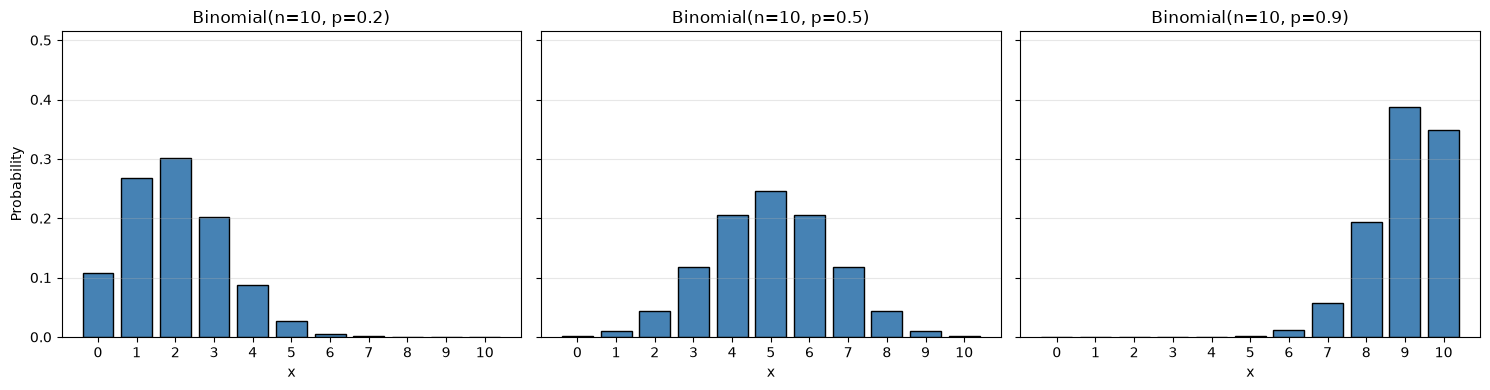

In [8]:
# Task 1 — Binomial PMFs in a row (fixed n, three p)
# --- Write your AI prompt here (Input → Process → Output) ---
# Input: scipy.stats.binom and matplotlib.pyplot.
#
# Process: create a figure with three subplots, each showing the PMF of a Binomial distribution with n=10 and p=0.2, 0.5, and 0.9 respectively.
#add comments to the code to explain what each part does.
#
# Output:print the PMF plots side by side for the three different probabilities.
#
# --- End prompt ---
# Fill Process + Output from the task (3 PMFs side by side). Then Inline Chat.
#
# --- generated / your code below ---
# Binomial PMFs for n=10 and p in {0.2, 0.5, 0.9}
# Set the fixed number of Bernoulli trials.
n = 10
# List the three probability values to compare.
ps = [0.2, 0.5, 0.9]
# Possible values of the Binomial random variable X are 0, 1, ..., n.
x = np.arange(0, n + 1)

# Create a 1x3 figure so the PMFs are shown side by side.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# For each probability p, compute and plot the PMF.
for ax, p in zip(axes, ps):
    pmf = binom.pmf(x, n, p)
    ax.bar(x, pmf, width=0.8, color="steelblue", edgecolor="black")
    ax.set_title(f"Binomial(n={n}, p={p})")
    ax.set_xlabel("x")
    ax.set_xticks(x)
    ax.set_ylim(0, max(pmf) * 1.2 + 0.05)  # Leave room above the tallest bar.
    ax.grid(axis="y", alpha=0.3)

# Label the y-axis for the first subplot only because they share the same scale.
axes[0].set_ylabel("Probability")

plt.tight_layout()
plt.show()


**Check:** Does the output make sense? Why? Type in the next cell, then **run** it.


In [3]:
# Task 1 — write BETWEEN the triple quotes, then RUN
task1_skew = """
# Skewness (p = 0.2 / 0.5 / 0.9):

"""
print(task1_skew)



# Skewness (p = 0.2 / 0.5 / 0.9):




## Task 2 — Standardizing does **not** create a Normal

**Question:** If we rescale a variable so it has mean 0 and variance 1, is the result always Normal?

Lecture: $Z = (X-\mu)/\sigma$ has **mean 0** and **variance 1**, but is Normal **only if** $X$ is Normal.

Let $X$ be **Exponential** (scale $= 2$). Draw 10,000 values, form $Z$, print mean/var of $Z$, histogram $X$ and $Z$, overlay $N(0,1)$ on $Z$.

Fill **Process** and **Output**, then Inline Chat.

**Done when:** mean of $Z$ is about $0$, variance about $1$, but $Z$ still looks **skewed**.


Sample mean of Z: -0.000
Sample variance of Z: 1.000


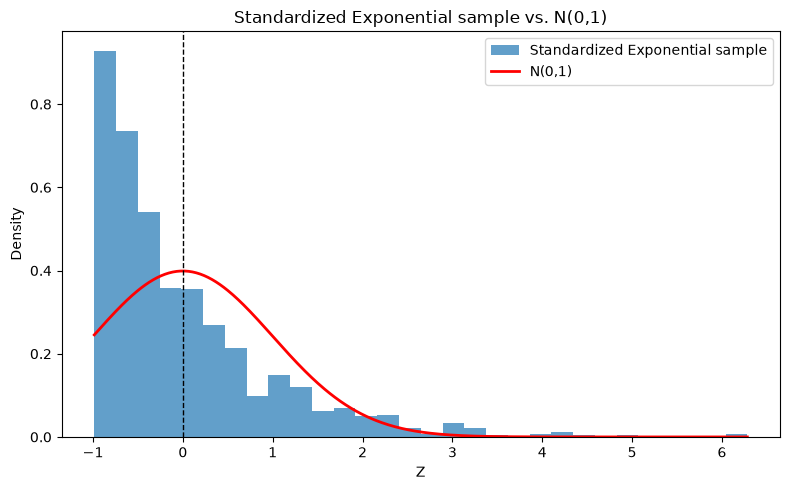

In [4]:
# Task 2 — Standardize a non-Normal X
# --- Write your AI prompt here (Input → Process → Output) ---
# Input: numpy, matplotlib.pyplot, rng, and scipy.stats.expon and scipy.stats.norm
#   are already available. 
# Process: create a random sample of size 1000 from an Exponential distribution with scale=2, standardize it, and plot the histogram of the standardized values along with the PDF of the standard Normal distribution for comparison.
#
#
# Output:print the histogram of the standardized Exponential sample and overlay the standard Normal PDF.
#
# --- End prompt ---
# Fill Process + Output, then Inline Chat. Read the code before running.
#
# --- generated / your code below ---
# Exponential sample, standardization, and comparison to N(0,1)
n = 1000
x = expon.rvs(scale=2.0, size=n, random_state=rng)

z = (x - x.mean()) / x.std(ddof=1)
print(f"Sample mean of Z: {z.mean():.3f}")
print(f"Sample variance of Z: {z.var(ddof=1):.3f}")

# Histogram of the standardized Exponential sample
grid = np.linspace(z.min(), z.max(), 500)

plt.figure(figsize=(8, 5))
plt.hist(z, bins=30, density=True, alpha=0.7, label="Standardized Exponential sample")
plt.plot(grid, norm.pdf(grid, loc=0, scale=1), "r-", lw=2, label="N(0,1)")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Standardized Exponential sample vs. N(0,1)")
plt.xlabel("Z")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


**Check:** mean/var of \(Z\) vs **shape** of \(Z\). Type 1–2 sentences in the next cell, then run it.


In [5]:
# Task 2 — write BETWEEN the triple quotes, then RUN
task5_z = """
# Mean/var of Z vs shape of Z:

"""
print(task5_z)



# Mean/var of Z vs shape of Z:




## Task 3 — Normal approximation and continuity correction

**Question:** A Binomial count is a whole number; a Normal curve is continuous. Why do we need a continuity correction when we approximate Binomial probabilities with a Normal?

Each Binomial bar sits on an integer and has **width 1**. The matching Normal area for that bar is from half a unit below to half a unit above — a **continuity correction**.

**Example**: **$n = 16$**, **$p = 0.5$**, so $np = 8 > 5$ and $n(1-p) = 8 > 5$. Let $X$ be Binomial; let $Y$ be Normal with the same mean $np$ and sd $\sqrt{np(1-p)}$.

1. Plot the Binomial PMF bars and overlay the Normal curve.
2. Print three values of $P(X \le 6)$: 
- exact Binomial; 
- Normal **without** correction ($Y \le 6$); 
- Normal **with** correction ($Y \le 6.5$).

Fill **Process** and **Output**, then Inline Chat.

**Done when:** one plot and three printed probabilities. If it helps, add vertical lines at 6 and 6.5 so the half-unit gap is easy to see.


Exact Binomial P(X <= 6): 0.227249
Normal without correction: 0.158655
Normal with continuity correction: 0.226627


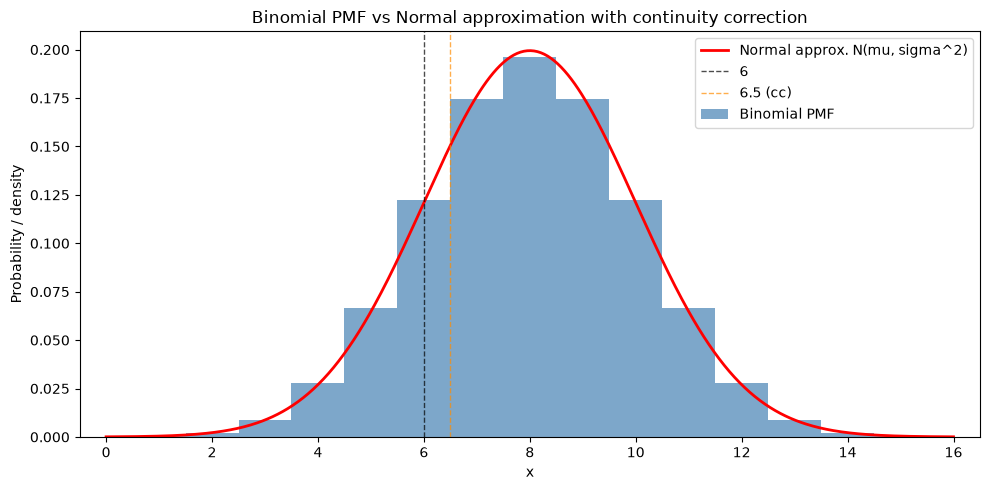

In [10]:
# Task 3 — Normal approx. + continuity correction
# Binomial setup
n = 16
p = 0.5
x = np.arange(0, n + 1)

# Exact Binomial probability
exact_prob = binom.cdf(6, n, p)

# Normal approximation parameters
mu = n * p
sigma = np.sqrt(n * p * (1 - p))

# Normal probabilities
normal_no_cc = norm.cdf(6, loc=mu, scale=sigma)
normal_with_cc = norm.cdf(6.5, loc=mu, scale=sigma)

# Print probabilities
print(f"Exact Binomial P(X <= 6): {exact_prob:.6f}")
print(f"Normal without correction: {normal_no_cc:.6f}")
print(f"Normal with continuity correction: {normal_with_cc:.6f}")

# Plot Binomial PMF and Normal approximation
x_grid = np.linspace(0, n, 500)
pmf = binom.pmf(x, n, p)
normal_pdf = norm.pdf(x_grid, loc=mu, scale=sigma)

plt.figure(figsize=(10, 5))
plt.bar(x, pmf, width=1.0, color="steelblue", alpha=0.7, label="Binomial PMF")
plt.plot(x_grid, normal_pdf, "r-", lw=2, label="Normal approx. N(mu, sigma^2)")
plt.axvline(6, color="black", linestyle="--", linewidth=1, alpha=0.7, label="6")
plt.axvline(6.5, color="darkorange", linestyle="--", linewidth=1, alpha=0.7, label="6.5 (cc)")
plt.xlim(-0.5, 16.5)
plt.xlabel("x")
plt.ylabel("Probability / density")
plt.title("Binomial PMF vs Normal approximation with continuity correction")
plt.legend()
plt.tight_layout()
plt.show()
# --- Write your AI prompt here (Input → Process → Output) ---
# Input: numpy, matplotlib.pyplot, scipy.stats.binom and scipy.stats.norm
#   are already imported.
# Process: create a Binomial distribution with n=16 and p=0.5, compute the probability of getting at most 6 successes using both the exact Binomial PMF and the Normal approximation with continuity correction, and plot both distributions for comparison.
#
#
# Output:print the exact Binomial probability and the Normal approximation probability, and display the plot comparing both distributions.
#give me the excact Binomial probability and the Normal approximation probability, and display the plot comparing both distributions.
#
# --- End prompt ---
# Fill Process + Output, then Inline Chat. Read the code before running.
#
# --- generated / your code below ---





**Check:** which Normal probability is closer to the exact Binomial $P(X \le 6)$? Type in the next cell, then run it.


In [ ]:
# Task 3 — write BETWEEN the triple quotes, then RUN
task3_cc = """
# Which Normal value is closer, and why add 0.5:

"""
print(task3_cc)


## Task 4 — Normal quantile from a probability

**Question:** In lecture we read a $z$-table *backwards*: given an area, find $z_0$. How do we do that in Python?

Lecture example: find $z_0$ if $P(Z < z_0) = 0.75$ (table: about $0.67$).

`scipy.stats.norm.ppf` is the inverse of `norm.cdf`: given a left-tail probability, it returns the cut-off.

Fill **Process** and **Output**, then Inline Chat.

**Done when:** the printed $z_0$ is close to $0.67$.


In [14]:
# Task 4 — Normal quantile (ppf)
# --- Write your AI prompt here (Input → Process → Output) ---
# Input: scipy.stats.norm is already imported.
# Process: using table or code, find the z-value such that P(Z <= z) = 0.75 for a standard Normal distribution.
#
#
# Output:print the z-value corresponding to the 75th percentile of the standard Normal distribution.
#
# --- End prompt ---
# Fill Process + Output, then Inline Chat. Read the code before running.
#
# --- generated / your code below ---
# Using the inverse CDF (percent point function) for the standard Normal:
z_0 = norm.ppf(0.75)

# Print the value corresponding to the 75th percentile
print(f"z_0 for P(Z <= z_0) = 0.75: z_0 = {z_0:.6f}")

z_0 for P(Z <= z_0) = 0.75: z_0 = 0.674490


**Check:** is the printed $z_0$ close to the lecture table value $0.67$? Type in the next cell, then run it.


## Before you leave — checklist
- [ ] Setup ran  
- [ ] **Task 1:** three Binomial PMFs + skewness note  
- [ ] **Task 2:** \(Z\) mean 0, var 1, still not Normal  
- [ ] **Task 3:** $P(X \le 6)$ exact vs Normal without/with $+0.5$ ($n=16$, $p=0.5$); you can say **why** we correct  
- [ ] **Task 4:** $z_0$ for $P(Z<z_0)=0.75$ via `norm.ppf` (about $0.67$)  
